# Fine-tuning de ViT-B/16 en Food-101

En este notebook hacemos **fine-tuning** del **Vision Transformer Base con parches de 16x16** (`ViT-B/16`, el modelo del paper *An Image is Worth 16x16 Words*) sobre el dataset **Food-101**, que contiene **101 clases de comida** con **1 000 imagenes por clase** (75 750 train + 25 250 test, ~5 GB en disco).

**Por que Food-101?**
- Imagenes a color en alta resolucion (no miniaturas).
- 101 clases visualmente desafiantes: hay pares dificiles como *pizza* vs *lasagna*, *ramen* vs *pho*, *donut* vs *beignet*. Es lo que se llama **fine-grained classification** (clasificacion de grano fino).
- Los errores del modelo son **interpretables**: ver una pizza confundida con lasagna ensena algo del modelo.
- Como hay clases muy parecidas, ademas de la **accuracy top-1** reportamos la **top-5** (cuenta como acierto si la clase real esta entre las 5 mas probables).

**Pasos del notebook**
1. Dependencias e imports.
2. Cargar `ViT-B/16` pre-entrenado en ImageNet y reemplazar la cabeza por una de 101 clases.
3. Preparar Food-101 con `torchvision.datasets.Food101` y dividirlo en train / val / test.
4. Entrenar (fine-tune) con AdamW + cosine schedule + mixed precision (AMP).
5. Evaluar en test (top-1 / top-5) y listar las clases que mas se confunden.
6. Visualizar predicciones en un grid de 5x5 con imagenes aleatorias.

## 1) Dependencias

Necesitamos las librerias estandar del ecosistema PyTorch:

- `torch` y `torchvision`: el framework y los datasets/transforms.
- `timm` (PyTorch Image Models): la libreria de Hugging Face que trae el ViT-B/16 pre-entrenado y otros cientos de modelos de vision listos para usar.
- `matplotlib`: para los plots y el grid de imagenes.
- `scikit-learn`: para el `classification_report` y la `confusion_matrix`.

In [1]:
# Si hace falta, descomenta:
# pip install -q timm torch torchvision matplotlib scikit-learn

In [2]:
import os
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import transforms

import timm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('timm version:', timm.__version__)

Device: cuda
timm version: 1.0.26


## 2) Cargar ViT-B/16 pre-entrenado y adaptar la cabeza

Usamos el checkpoint `vit_base_patch16_224.augreg_in21k_ft_in1k`, que viene **pre-entrenado en ImageNet-21k y luego fine-tuned en ImageNet-1k**. El nombre describe la variante:

- `vit_base` -> tamano **Base** (12 capas, 768 dim, ~86M params).
- `patch16` -> parches de **16 x 16** pixeles.
- `224` -> resolucion de entrada.

Al pasar `num_classes=101`, `timm` **reemplaza automaticamente la cabeza** original (`Linear(768 -> 1000)` de ImageNet) por una nueva `Linear(768 -> 101)` inicializada de forma aleatoria. El resto del backbone conserva los pesos pre-entrenados.

Como Food-101 tiene mas de 75k imagenes de entrenamiento, hacemos **full fine-tuning** (entrenamos todo el modelo, no solo la cabeza). Para datasets mas chicos seria mejor hacer *linear probing* (congelar el backbone y entrenar solo la cabeza nueva).

In [3]:
NUM_CLASSES = 101

model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=NUM_CLASSES,
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totales:     {n_params/1e6:.2f} M')
print(f'Parametros entrenables: {n_trainable/1e6:.2f} M')
print('Cabeza:', model.head)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Parametros totales:     85.88 M
Parametros entrenables: 85.88 M
Cabeza: Linear(in_features=768, out_features=101, bias=True)


## 3) Datos: Food-101 con split train / val / test

`torchvision.datasets.Food101` descarga el dataset oficial (~5 GB) la primera vez. Trae solo dos splits oficiales (`train` y `test`), asi que creamos el conjunto de validacion a partir del train:

| Split | Tamano | Uso |
|---|---|---|
| **train** | 65 650 (650 imgs/clase) | Entrenar los pesos |
| **val**   | 10 100 (100 imgs/clase) | Monitorear cada epoca para ajustar hiperparametros |
| **test**  | 25 250 (250 imgs/clase) | Evaluacion FINAL (no se toca durante el entrenamiento) |

El split de val es **estratificado**: tomamos los ultimos 100 indices de cada clase del train oficial, asi cada clase queda igualmente representada.

**Detalles del preprocesamiento:**
- Las imagenes vienen en tamanos variables y son grandes. ViT-B/16 espera entradas de **224 x 224**, asi que en `eval_tf` hacemos `Resize(256)` + `CenterCrop(224)`, y en `train_tf` usamos `RandomResizedCrop(224)` para meter algo de augmentation.
- Solo aplicamos augmentation (`RandomHorizontalFlip`, `ColorJitter`) en **train**; en val y test usamos un pipeline limpio.
- Normalizamos con la **media/std de ImageNet** porque el backbone fue pre-entrenado con esa estadistica.
- Si corres en **Google Colab**, el dataset se guarda en tu **Drive** para reutilizarlo en futuras sesiones y evitar descargas repetidas.
- La primera ejecucion descarga ~5 GB; las siguientes usan cache local/Drive.


In [4]:
import importlib
import importlib.util

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Guardar dataset en Drive si estamos en Colab; si no, usar ruta local del proyecto.
if importlib.util.find_spec('google.colab') is not None:
    drive = importlib.import_module('google.colab.drive')
    drive.mount('/content/drive', force_remount=False)
    data_dir = '/content/drive/MyDrive/Proyecto-Clasificador/data'
    print('Entorno: Google Colab -> usando Drive para cache de dataset')
else:
    data_dir = './data'
    print('Entorno: local -> usando carpeta', data_dir)

os.makedirs(data_dir, exist_ok=True)

# Dos copias del split 'train' oficial: una con augmentation, otra limpia (para val)
trainval_aug   = torchvision.datasets.Food101(root=data_dir, split='train', download=True, transform=train_tf)
trainval_clean = torchvision.datasets.Food101(root=data_dir, split='train', download=False, transform=eval_tf)
test_set       = torchvision.datasets.Food101(root=data_dir, split='test',  download=True, transform=eval_tf)

CLASSES = trainval_aug.classes
print(f'Total clases: {len(CLASSES)}')
print('Primeras 10:', CLASSES[:10])
print('Ruta de dataset:', data_dir)


Mounted at /content/drive
Entorno: Google Colab -> usando Drive para cache de dataset


100%|██████████| 5.00G/5.00G [04:20<00:00, 19.2MB/s] 


Total clases: 101
Primeras 10: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']
Ruta de dataset: /content/drive/MyDrive/Proyecto-Clasificador/data


In [5]:
# Split estratificado: ultimos VAL_PER_CLASS indices de cada clase -> val
VAL_PER_CLASS = 100

labels = np.array(trainval_aug._labels)  # tensor de etiquetas internas de Food101
train_idx, val_idx = [], []
for c in range(NUM_CLASSES):
    idx_c = np.where(labels == c)[0]
    val_idx.extend(idx_c[-VAL_PER_CLASS:].tolist())
    train_idx.extend(idx_c[:-VAL_PER_CLASS].tolist())

train_set = Subset(trainval_aug,   train_idx)
val_set   = Subset(trainval_clean, val_idx)

BATCH = 64 if device.type == 'cuda' else 16
NUM_WORKERS = 4 if device.type == 'cuda' else 2

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}  Batch: {BATCH}')

Train: 65650  Val: 10100  Test: 25250  Batch: 64


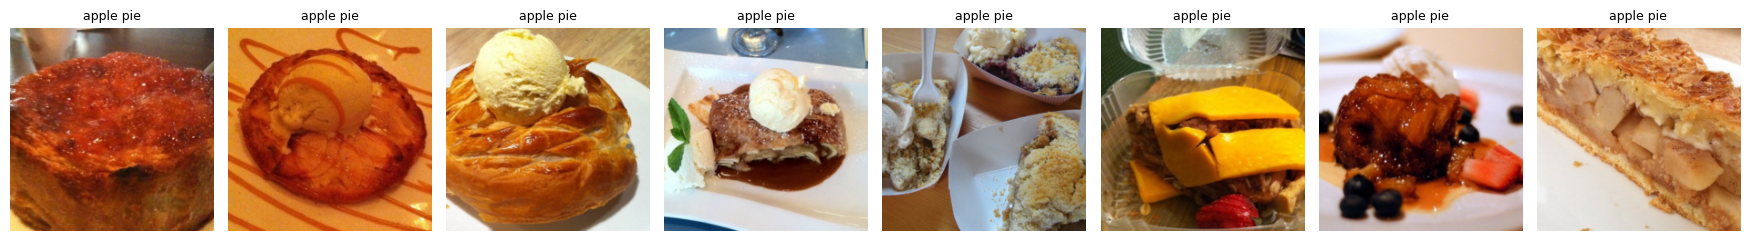

In [6]:
# Visualizar algunas imagenes con su clase
def desnormalizar(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)

x, y = next(iter(val_loader))
n = 8
fig, axes = plt.subplots(1, n, figsize=(2.2*n, 2.6))
for i in range(n):
    img = desnormalizar(x[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(CLASSES[y[i]].replace('_', ' '), fontsize=9)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## 4) Loop de entrenamiento

Configuracion siguiendo las recomendaciones del paper de ViT y de `timm` para fine-tuning:

- **Optimizador AdamW** con `lr=3e-5` (LR bajo: los pesos pre-entrenados ya son buenos, solo queremos ajustarlos un poco) y `weight_decay=0.05`.
- **Cosine schedule con warmup** del 10%: el LR sube linealmente al inicio y luego decae como un coseno hasta cero.
- **Cross-entropy con `label_smoothing=0.1`**: en lugar de pedir probabilidad 1.0 a la clase correcta, repartimos un poco entre las demas. Ayuda con clases visualmente parecidas.
- **Mixed precision (AMP)** con la API moderna `torch.amp.autocast('cuda')` y `torch.amp.GradScaler('cuda')`: hace forward/backward en float16 y duplica aproximadamente la velocidad sin perder precision.
- **Gradient clipping** a norma 1.0 para estabilizar.
- En cada epoca evaluamos en **val** (no en test) para monitorear progreso y detectar overfitting.

Con 5 epocas y una GPU como T4/A100/H100 esperamos llegar a **~88-90% top-1** en test (el paper de ViT reporta ~90% en Food-101).

In [7]:
EPOCHS = 5
LR = 3e-5
WD = 0.05
WARMUP_FRAC = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_FRAC)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = (device.type == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f'Total steps: {total_steps}  Warmup: {warmup_steps}  AMP: {use_amp}')

Total steps: 5130  Warmup: 513  AMP: True


In [8]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct1 = correct5 = total = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        top5 = logits.topk(5, dim=1).indices
        correct1 += (top5[:, 0] == y).sum().item()
        correct5 += (top5 == y.unsqueeze(1)).any(dim=1).sum().item()
        total += x.size(0)
    return loss_sum / total, correct1 / total, correct5 / total

In [9]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_top5': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    running_correct = 0
    seen = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * x.size(0)
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        seen += x.size(0)

        if (i + 1) % 100 == 0:
            print(f'  epoch {epoch}  step {i+1}/{len(train_loader)}  loss {running_loss/seen:.4f}  lr {scheduler.get_last_lr()[0]:.2e}')

    train_loss = running_loss / seen
    train_acc  = running_correct / seen
    val_loss, val_acc, val_top5 = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_top5'].append(val_top5)

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'train_loss {train_loss:.4f}  train_acc {train_acc*100:.2f}%  '
          f'val_loss {val_loss:.4f}  val_top1 {val_acc*100:.2f}%  val_top5 {val_top5*100:.2f}%  '
          f'({time.time()-t0:.1f}s)')

/tmp/ipykernel_904/2102938764.py:23: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  epoch 1  step 100/1026  loss 5.3815  lr 5.85e-06
  epoch 1  step 200/1026  loss 4.3879  lr 1.17e-05
  epoch 1  step 300/1026  loss 3.5988  lr 1.75e-05
  epoch 1  step 400/1026  loss 3.1358  lr 2.34e-05
  epoch 1  step 500/1026  loss 2.8363  lr 2.92e-05
  epoch 1  step 600/1026  loss 2.6304  lr 3.00e-05
  epoch 1  step 700/1026  loss 2.4722  lr 2.99e-05
  epoch 1  step 800/1026  loss 2.3480  lr 2.97e-05
  epoch 1  step 900/1026  loss 2.2494  lr 2.95e-05
  epoch 1  step 1000/1026  loss 2.1663  lr 2.92e-05
Epoch 1/5  train_loss 2.1473  train_acc 64.95%  val_loss 1.4417  val_top1 80.88%  val_top5 95.03%  (273.1s)
  epoch 2  step 100/1026  loss 1.2780  lr 2.87e-05
  epoch 2  step 200/1026  loss 1.2725  lr 2.83e-05
  epoch 2  step 300/1026  loss 1.2766  lr 2.78e-05
  epoch 2  step 400/1026  loss 1.2724  lr 2.72e-05
  epoch 2  step 500/1026  loss 1.2706  lr 2.66e-05
  epoch 2  step 600/1026  loss 1.2668  lr 2.59e-05
  epoch 2  step 700/1026  loss 1.2658  lr 2.52e-05
  epoch 2  step 800/1026

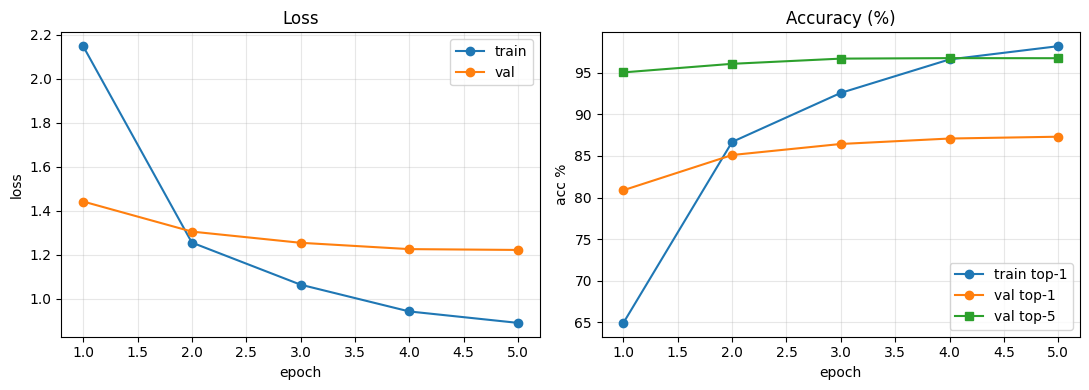

In [10]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs_x, history['train_loss'], marker='o', label='train')
ax[0].plot(epochs_x, history['val_loss'],   marker='o', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(epochs_x, [a*100 for a in history['train_acc']], marker='o', label='train top-1')
ax[1].plot(epochs_x, [a*100 for a in history['val_acc']],   marker='o', label='val top-1')
ax[1].plot(epochs_x, [a*100 for a in history['val_top5']],  marker='s', label='val top-5')
ax[1].set_title('Accuracy (%)'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('acc %')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5) Evaluacion final en test

Ahora corremos el modelo final sobre el conjunto de **test** (25 250 imagenes) y reportamos:

- **Top-1 accuracy**: porcentaje en el que la clase mas probable es la correcta.
- **Top-5 accuracy**: porcentaje en el que la clase real esta entre las 5 mas probables. Con 101 clases parecidas (pizza, lasagna, calzone, ravioli...) la top-5 es muy informativa: si el modelo se equivoca pero "la duda razonable" estaba entre las opciones, el error es comprensible.
- **classification_report**: precision, recall y F1 por clase para ver donde el modelo flaquea mas.

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_pred1, all_pred5, all_true = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
        top5 = logits.topk(5, dim=1).indices.cpu()
        all_pred1.append(top5[:, 0])
        all_pred5.append(top5)
        all_true.append(y)
    return (torch.cat(all_pred1).numpy(),
            torch.cat(all_pred5).numpy(),
            torch.cat(all_true).numpy())

y_pred1, y_pred5, y_true = predict_all(model, test_loader)
test_top1 = (y_pred1 == y_true).mean()
test_top5 = (y_pred5 == y_true[:, None]).any(axis=1).mean()
print(f'Test top-1: {test_top1*100:.2f}%')
print(f'Test top-5: {test_top5*100:.2f}%')

Test top-1: 91.80%
Test top-5: 98.65%


In [12]:
# Pares de clases mas confundidas (off-diagonal mas grandes en la matriz de confusion)
cm = confusion_matrix(y_true, y_pred1)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

TOP_CONF = 15
flat_idx = np.argsort(cm_off.ravel())[::-1][:TOP_CONF]
rows, cols = np.unravel_index(flat_idx, cm_off.shape)

print(f'Top {TOP_CONF} pares mas confundidos (real -> predicho):')
print('-' * 60)
for r, c in zip(rows, cols):
    print(f'  {CLASSES[r]:30s} -> {CLASSES[c]:30s}  ({cm_off[r, c]} veces)')

Top 15 pares mas confundidos (real -> predicho):
------------------------------------------------------------
  steak                          -> filet_mignon                    (45 veces)
  filet_mignon                   -> steak                           (26 veces)
  steak                          -> pork_chop                       (20 veces)
  tuna_tartare                   -> beef_tartare                    (19 veces)
  steak                          -> prime_rib                       (18 veces)
  apple_pie                      -> bread_pudding                   (18 veces)
  prime_rib                      -> steak                           (17 veces)
  chocolate_cake                 -> chocolate_mousse                (15 veces)
  beef_tartare                   -> tuna_tartare                    (15 veces)
  chocolate_mousse               -> chocolate_cake                  (15 veces)
  dumplings                      -> gyoza                           (15 veces)
  falafel            

In [13]:
# Reporte por clase (precision/recall/f1)
print(classification_report(y_true, y_pred1, target_names=CLASSES, digits=3))

                         precision    recall  f1-score   support

              apple_pie      0.813     0.764     0.788       250
         baby_back_ribs      0.923     0.916     0.920       250
                baklava      0.960     0.948     0.954       250
         beef_carpaccio      0.923     0.960     0.941       250
           beef_tartare      0.893     0.900     0.896       250
             beet_salad      0.873     0.856     0.865       250
               beignets      0.903     0.936     0.919       250
               bibimbap      0.948     0.948     0.948       250
          bread_pudding      0.802     0.812     0.807       250
      breakfast_burrito      0.902     0.844     0.872       250
             bruschetta      0.905     0.876     0.890       250
           caesar_salad      0.933     0.948     0.940       250
                cannoli      0.953     0.976     0.964       250
          caprese_salad      0.894     0.944     0.918       250
            carrot_cake 

## 6) Predicciones de ejemplo (test)

Para ver cualitativamente como se comporta el modelo, mostramos un **grid de 5x5 con imagenes aleatorias del set de test**. Cada celda muestra:

- La imagen real.
- La clase verdadera (`real:`) y la prediccion del modelo (`pred:`) con su confianza en %.
- El titulo va en **verde si acerto** y en **rojo si fallo**.

En la parte superior se reporta la accuracy de este grid concreto (con 25 imagenes hay variacion entre corridas, pero suele rondar la accuracy global del modelo en test).

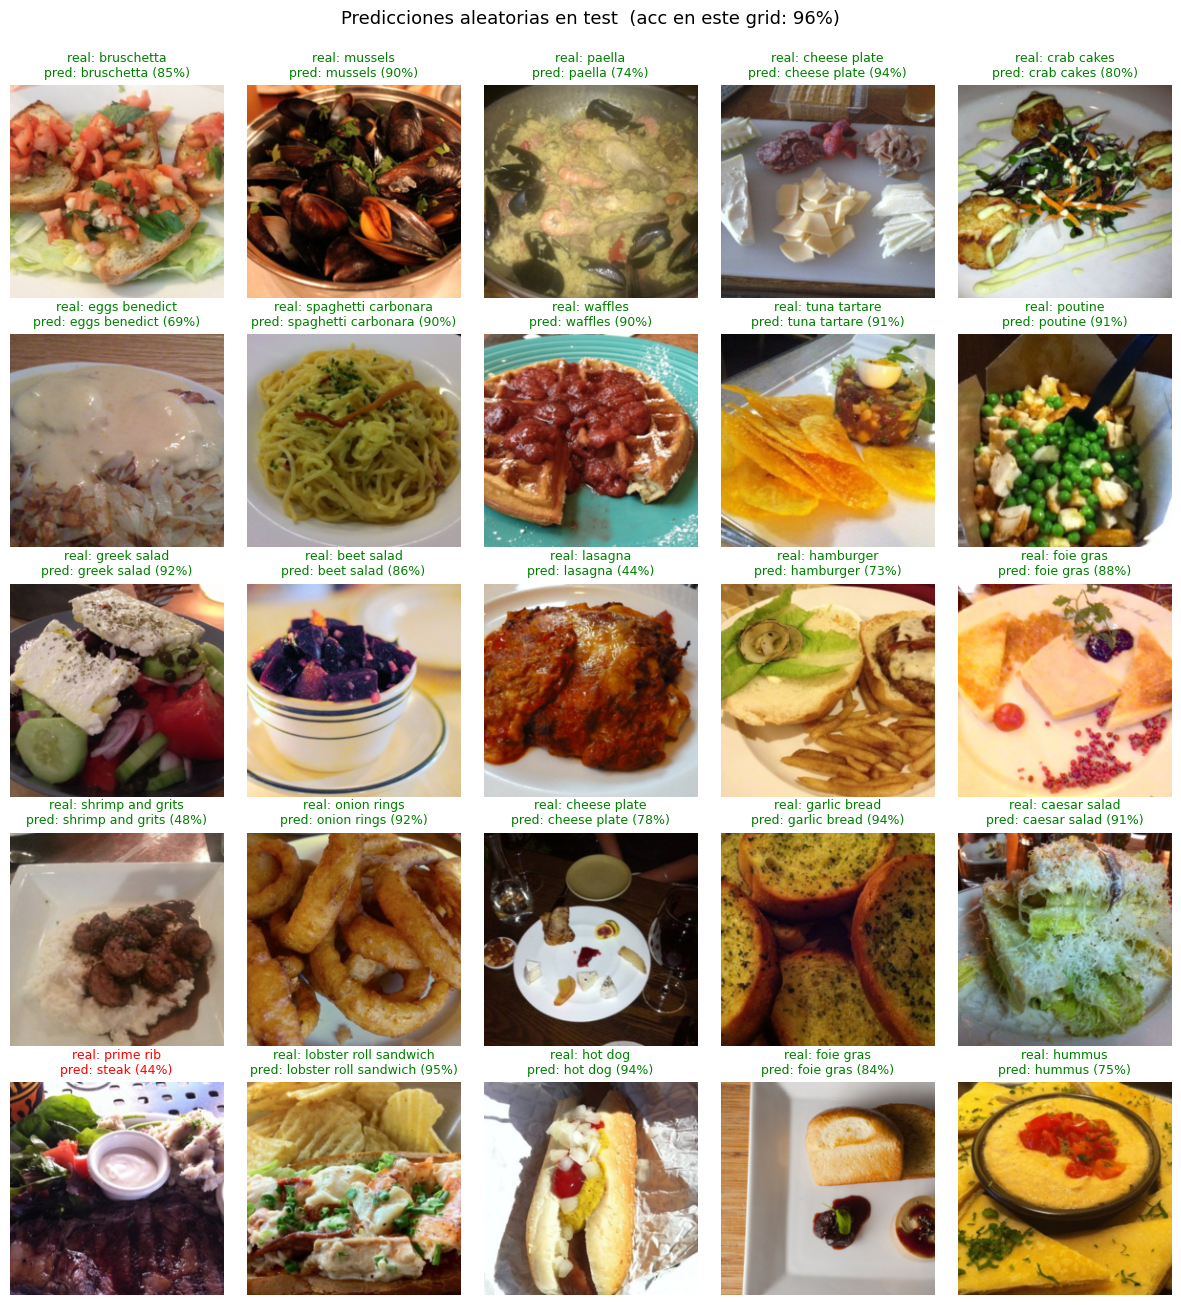

In [14]:
# Grid 5x5 con predicciones aleatorias del set de test
GRID = 5
N_TOTAL = GRID * GRID

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(test_set), size=N_TOTAL, replace=False)

# Cargar las 25 imagenes seleccionadas y predecir en un solo batch
imgs, labels_true = zip(*[test_set[i] for i in sample_idx])
x_batch = torch.stack(imgs).to(device)
y_batch = torch.tensor(labels_true)

model.eval()
with torch.no_grad(), torch.amp.autocast('cuda', enabled=use_amp):
    probs = F.softmax(model(x_batch).float(), dim=1).cpu()
preds = probs.argmax(dim=1)
confs = probs.gather(1, preds.unsqueeze(1)).squeeze(1)

fig, axes = plt.subplots(GRID, GRID, figsize=(2.4*GRID, 2.6*GRID))
for k, ax in enumerate(axes.flat):
    img = desnormalizar(x_batch[k]).permute(1, 2, 0).numpy()
    ax.imshow(img); ax.axis('off')
    correct = (preds[k].item() == y_batch[k].item())
    color = 'green' if correct else 'red'
    real = CLASSES[y_batch[k]].replace('_', ' ')
    pred = CLASSES[preds[k]].replace('_', ' ')
    ax.set_title(f'real: {real}\npred: {pred} ({confs[k]*100:.0f}%)',
                 fontsize=9, color=color)

acc_grid = (preds == y_batch).float().mean().item()
plt.suptitle(f'Predicciones aleatorias en test  (acc en este grid: {acc_grid*100:.0f}%)',
             fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

## 7) Guardar el modelo

Guardamos el modelo entrenado para poder cargarlo despues sin tener que volver a entrenar. Funciona tanto en **Google Colab** (guarda en tu Drive) como en **local** (guarda en la carpeta `models/` del repo).

Lo que guardamos:
- `model_state_dict`: los pesos del modelo (~330 MB en float32).
- `arch`: el nombre del checkpoint de `timm`, para reconstruir la arquitectura exacta al cargar.
- `classes`: la lista de nombres de las 101 clases.
- Metricas finales (`test_top1`, `test_top5`) para tener trazabilidad.


In [16]:
import importlib
import importlib.util

# Determinar carpeta de destino: Google Drive si estamos en Colab, ../models si no
if importlib.util.find_spec('google.colab') is not None:
    drive = importlib.import_module('google.colab.drive')
    drive.mount('/content/drive', force_remount=False)
    SAVE_DIR = '/content/drive/MyDrive/Proyecto-Clasificador/models'
    print('Entorno: Google Colab -> guardando en Drive')
else:
    SAVE_DIR = '../models'
    print('Entorno: local -> guardando en', SAVE_DIR)

os.makedirs(SAVE_DIR, exist_ok=True)
ckpt_path = os.path.join(SAVE_DIR, 'vit_b16_food101_finetuned.pth')

torch.save({
    'model_state_dict': model.state_dict(),
    'arch': 'vit_base_patch16_224.augreg_in21k_ft_in1k',
    'num_classes': NUM_CLASSES,
    'classes': CLASSES,
    'test_top1': float(test_top1),
    'test_top5': float(test_top5),
    'epochs': EPOCHS,
}, ckpt_path)

size_mb = os.path.getsize(ckpt_path) / 1e6
print(f'Modelo guardado en: {ckpt_path}')
print(f'Tamano: {size_mb:.1f} MB')
print(f'Test top-1: {test_top1*100:.2f}%  Test top-5: {test_top5*100:.2f}%')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab -> guardando en Drive
Modelo guardado en: /content/drive/MyDrive/Proyecto-Clasificador/models/vit_b16_food101_finetuned.pth
Tamano: 343.6 MB
Test top-1: 91.80%  Test top-5: 98.65%


Lo que hicimos en este notebook:

- Cargamos `ViT-B/16` pre-entrenado en ImageNet via `timm` y dejamos que reemplazara la cabeza automaticamente para tener 101 salidas.
- Preparamos Food-101 con un split estratificado **train / val / test** (65 650 / 10 100 / 25 250).
- Hicimos **full fine-tuning** (todos los pesos entrenables) durante 5 epocas con AdamW, cosine schedule y mixed precision.
- Evaluamos con **top-1 y top-5 accuracy**, listamos los pares de clases mas confundidas y mostramos un **grid 5x5 de predicciones aleatorias** del test.